# Jour 3 — CNN : pneumonie bactérienne vs virale (radiographie thoracique)

Classification binaire d'images en trois itérations sur le même problème :

1. TP1 — CNN from scratch (overfitting attendu)
2. TP2 — CNN + data augmentation + Dropout
3. TP3 — Transfer learning MobileNetV2

Modèle éducatif : il ne constitue en aucun cas un outil de diagnostic médical.

Dataset : radiographies de pneumonie labellisées bactérienne / virale (Kaggle, ~3 900 images). On ne garde que les clichés pathologiques et on distingue l'origine de l'infection — une tâche fine bien plus difficile que « normal vs pneumonie » : les deux motifs (consolidation lobaire bactérienne, atteinte interstitielle diffuse virale) se recouvrent largement, y compris pour un radiologue. Les classes sont déséquilibrées (~1,9:1 en faveur du bactérien) ; on le traite avec `class_weight` à l'entraînement, pas en jetant des données.

## Phase 1.1 — Setup et organisation du dataset

Télécharger le dataset via l'API Kaggle, nettoyer l'archive, puis organiser les images en `train` / `val` / `test` par classe.

Le dataset ne fournit pas de dossiers `bacteria` / `virus` : le type d'infection est encodé dans le nom de chaque fichier de pneumonie (`personXX_bacteria_YY.jpeg`, `personXX_virus_YY.jpeg`). On trie donc les images sur ce motif et on ignore les clichés `normal`.

- **test** : le split officiel du dataset (patient-disjoint), conservé tel quel pour une évaluation finale honnête.
- **train / val** : le `val` officiel ne fait que 16 images, donc on regroupe train + val officiels et on refait un split 80/20 (`seed=42`).

Environnement : conteneur Docker (TensorFlow CPU). Identifiants Kaggle via `KAGGLE_USERNAME` / `KAGGLE_KEY` (`.env`). Données dans des volumes Docker (`/tf/raw`, `/tf/data`).

In [1]:
# Seul endroit à modifier pour changer de dataset.
CLASS_A = 'bacteria'
CLASS_B = 'virus'

# Les deux classes vivent dans le même dossier PNEUMONIA de l'archive ; on les
# distingue par un motif présent dans le nom de fichier (personXX_bacteria_YY.jpeg).
CLASS_SRC = 'PNEUMONIA'

# Volumes Docker (rapides, hors bind mount Windows).
RAW_ROOT  = '/tf/raw'
DATA_ROOT = '/tf/data'

KAGGLE_DATASET = 'paultimothymooney/chest-xray-pneumonia'

# Entrée réseau : 64-160 px conseillé, 128 = compromis détail / temps CPU.
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

In [2]:
import os, subprocess, shutil

# Identifiants lus depuis KAGGLE_USERNAME / KAGGLE_KEY (voir .env). ~2,3 Go au premier run.
os.makedirs(RAW_ROOT, exist_ok=True)
if not any(os.scandir(RAW_ROOT)):
    subprocess.run(
        ['kaggle', 'datasets', 'download', '-d', KAGGLE_DATASET,
         '-p', RAW_ROOT, '--unzip', '-q'],
        check=True,
    )
    print('Téléchargement terminé.')
else:
    print('Dataset déjà présent, téléchargement ignoré.')

# Nettoyage de l'archive : ce dataset embarque une copie imbriquée chest_xray/chest_xray
# et des dossiers __MACOSX (métadonnées macOS). On les retire pour garder une structure
# propre : chest_xray/{train,val,test}/{NORMAL,PNEUMONIA}.
nested = os.path.join(RAW_ROOT, 'chest_xray', 'chest_xray')
if os.path.isdir(nested):
    shutil.rmtree(nested)
    print('Retiré : chest_xray/chest_xray')
for dirpath, dirs, files in os.walk(RAW_ROOT):
    if '__MACOSX' in dirs:
        shutil.rmtree(os.path.join(dirpath, '__MACOSX'))
        dirs.remove('__MACOSX')
        print('Retiré :', os.path.join(os.path.relpath(dirpath, RAW_ROOT), '__MACOSX'))

Dataset déjà présent, téléchargement ignoré.


In [3]:
# Structure du dataset après nettoyage.
for dirpath, dirs, files in os.walk(os.path.join(RAW_ROOT, 'chest_xray')):
    imgs = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    niveau = dirpath.replace(RAW_ROOT, '').count(os.sep)
    print('  ' * niveau, os.path.basename(dirpath), '->', len(imgs), 'images')

   chest_xray -> 0 images
     val -> 0 images
       NORMAL -> 8 images
       PNEUMONIA -> 8 images
     test -> 0 images
       NORMAL -> 234 images
       PNEUMONIA -> 390 images
     train -> 0 images
       NORMAL -> 1341 images
       PNEUMONIA -> 3875 images


In [4]:
import random

BASE = os.path.join(RAW_ROOT, 'chest_xray')
IMG_EXT = ('.jpg', '.jpeg', '.png')

def images_in(split, cls):
    # Images du dossier PNEUMONIA dont le nom contient le motif de la classe.
    d = os.path.join(BASE, split, CLASS_SRC)
    if not os.path.isdir(d):
        return []
    return [os.path.join(d, f) for f in os.listdir(d)
            if f.lower().endswith(IMG_EXT) and not f.startswith('._') and cls in f.lower()]

def copy_to(paths, split, cls):
    dst = os.path.join(DATA_ROOT, split, cls)
    os.makedirs(dst, exist_ok=True)
    for i, src in enumerate(paths):
        ext = os.path.splitext(src)[1].lower()
        shutil.copy(src, os.path.join(dst, f'{cls}_{i:05d}{ext}'))

# Repartir de dossiers propres. DATA_ROOT est un point de montage : on vide son
# contenu au lieu de le supprimer lui-même.
if os.path.isdir(DATA_ROOT):
    for e in os.scandir(DATA_ROOT):
        shutil.rmtree(e.path) if e.is_dir() else os.remove(e.path)

random.seed(42)
for cls in [CLASS_A, CLASS_B]:
    # test : split officiel conservé tel quel (patient-disjoint).
    copy_to(images_in('test', cls), 'test', cls)
    # train/val : regroupe train + val officiels puis re-split 80/20.
    pool = images_in('train', cls) + images_in('val', cls)
    random.shuffle(pool)
    n_val = int(len(pool) * 0.2)
    copy_to(pool[:n_val], 'val', cls)
    copy_to(pool[n_val:], 'train', cls)

In [5]:
# Comptes par split et par classe : le déséquilibre ~1,9:1 doit rester visible.
for split in ['train', 'val', 'test']:
    for cls in [CLASS_A, CLASS_B]:
        path = os.path.join(DATA_ROOT, split, cls)
        print(f'{path} : {len(os.listdir(path))} images')

/tf/data/train/bacteria : 2031 images
/tf/data/train/virus : 1076 images
/tf/data/val/bacteria : 507 images
/tf/data/val/virus : 269 images
/tf/data/test/bacteria : 242 images
/tf/data/test/virus : 148 images


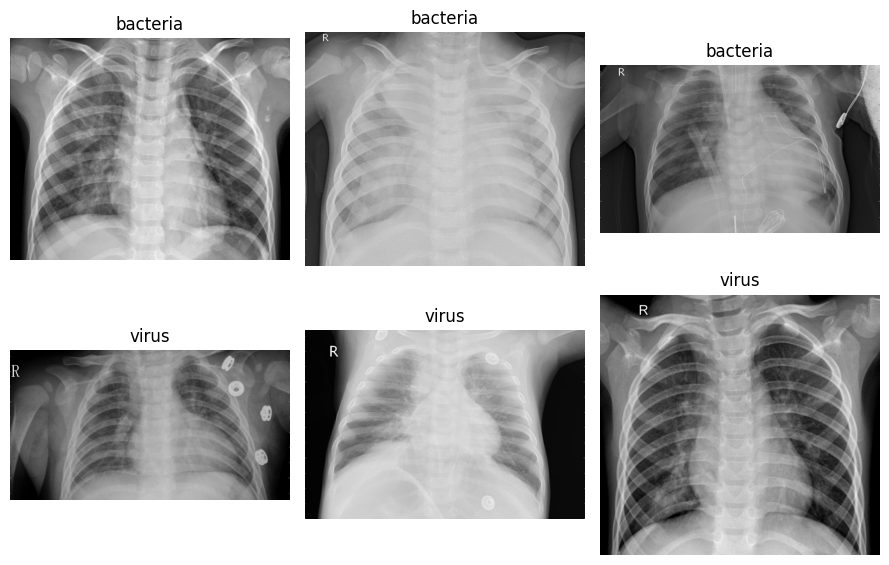

In [6]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plt.figure(figsize=(9, 6))
for i, cls in enumerate([CLASS_A, CLASS_B]):
    folder = os.path.join(DATA_ROOT, 'train', cls)
    for j, fname in enumerate(os.listdir(folder)[:3]):
        img = mpimg.imread(os.path.join(folder, fname))
        plt.subplot(2, 3, i * 3 + j + 1)
        plt.imshow(img, cmap='gray')
        plt.title(cls)
        plt.axis('off')
plt.tight_layout()
plt.show()

## Phase 1.2 — Preprocessing : normalisation + batching

Chargement avec `image_dataset_from_directory` (`label_mode='binary'` : bacteria=0, virus=1 par ordre alphabétique), normalisation des pixels en [0,1] avec `Rescaling(1./255)`, puis `cache()` + `prefetch()` pour ne pas relire le disque à chaque epoch. `shuffle=True` sur train uniquement ; le val set garde un ordre fixe pour des évaluations reproductibles.

In [7]:
import tensorflow as tf

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_ROOT, 'train'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=True,
    seed=42,
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_ROOT, 'val'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False,
    seed=42,
)
print('Classes :', train_ds.class_names)

2026-07-16 13:44:05.055305: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-16 13:44:05.164122: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Found 3107 files belonging to 2 classes.


Found 776 files belonging to 2 classes.


Classes : ['bacteria', 'virus']


In [8]:
# Rescaling en [0,1] pour TP1/TP2 ; TP3 utilisera preprocess_input à la place.
normalization_layer = tf.keras.layers.Rescaling(1./255)
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(buffer_size=AUTOTUNE)

In [9]:
# Vérification du premier batch : shapes et plage de valeurs après Rescaling.
images, labels = next(iter(train_ds))
print('Shape images batch :', images.shape)
print('Shape labels batch :', labels.shape)
print(f'Valeurs : min = {tf.reduce_min(images):.2f}, max = {tf.reduce_max(images):.2f}')

Shape images batch : (32, 128, 128, 3)
Shape labels batch : (32, 1)
Valeurs : min = 0.00, max = 1.00


2026-07-16 13:44:08.760470: W tensorflow/core/kernels/data/cache_dataset_ops.cc:914] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


## Phase 1.3 — Architecture CNN from scratch

Trois blocs Conv2D + MaxPooling, puis Flatten et deux Dense. Avec `padding='same'`, chaque Conv2D conserve H×W et seul le MaxPooling (2,2) divise par 2. Calcul des shapes à la main pour une entrée 128×128×3 :

| Couche | Shape en sortie | Paramètres |
|---|---|---|
| Conv2D(32) + MaxPool | (64, 64, 32) | 3×3×3×32 + 32 = 896 |
| Conv2D(64) + MaxPool | (32, 32, 64) | 3×3×32×64 + 64 = 18 496 |
| Conv2D(128) + MaxPool | (16, 16, 128) | 3×3×64×128 + 128 = 73 856 |
| Flatten | (32 768,) | 0 |
| Dense(128) | (128,) | 32 768×128 + 128 = 4 194 432 |
| Dense(1, sigmoid) | (1,) | 129 |

Total attendu : **4 287 809 paramètres**, dont l'écrasante majorité dans le Dense après Flatten — c'est cette couche qui donnera au modèle sa capacité à mémoriser (et donc à overfitter).

In [10]:
from tensorflow.keras import layers, models

def build_cnn_scratch(input_shape):
    """CNN from scratch pour la classification binaire.

    Architecture délibérément simple : on veut voir l'overfitting, pas l'éviter.
    """
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(1, activation='sigmoid'),
    ])
    return model

model_scratch = build_cnn_scratch(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
model_scratch.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,287,809 (16.36 MB)

 Trainable params: 4,287,809 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model_scratch.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'],
)